## MoveJ and MoveL

#### 0. Load Curobo Header

In [1]:
import copy
from curobo.config_io import load_yaml
from curobo.content import get_robot_configs_path
from curobo.viewer import ViserVisualizer
from curobo.types import GoalToolPose, JointState, Pose
from curobo.inverse_kinematics import InverseKinematics, InverseKinematicsCfg
import torch
import numpy as np
import matplotlib.pyplot as plt

_ViserVisualizerClass = ViserVisualizer

def ViserVisualizer(*args, **kwargs):
    global _shared_viz
    if "_shared_viz" not in globals():
        # The later notebook sections use robot spheres.
        kwargs["visualize_robot_spheres"] = True
        _shared_viz = _ViserVisualizerClass(*args, **kwargs)
    return _shared_viz

robot_config = load_yaml(str(get_robot_configs_path() / "franka.yml"))
robot_config["robot_cfg"]["kinematics"]["tool_frames"] = ["ee_link"]
viz = ViserVisualizer(content_path=copy.deepcopy(robot_config), add_control_frames = False)

gui = viz._server.gui

if not hasattr(gui, "_original_add_slider"):
    gui._original_add_slider = gui.add_slider

    def add_slider_replacing_previous(*args, **kwargs):
        gui.reset()
        return gui._original_add_slider(*args, **kwargs)

    gui.add_slider = add_slider_replacing_previous

# draw frame
def draw_frame(viz, pose, name):
    frame = viz.add_frame(name, pose)
    frame.axes_length = 0.1
    frame.axes_radius = 0.005
    frame.origin_radius = 0.01

╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Connection opened (0, 1 total), 179 persistent messages

(viser) Connection closed (0, 0 total)

(viser) Connection opened (1, 1 total), 179 persistent messages

move J and move L move J is coarse movement not super accurate but move L is very accurate and precise but it lacks collision avoidance capabilities.

#### 1. Move Joint (MoveJ)

In [2]:
# draw frame
F1 = Pose.from_list([0.5, 0.0, 0.3, 0.0, 1.0, 0.0, 0.0])
draw_frame(viz, F1, "F1")

# compute IK
ik = InverseKinematics(InverseKinematicsCfg.create(robot=robot_config))
goal = GoalToolPose.from_poses({"ee_link": F1}, num_goalset=1)
result = ik.solve_pose(goal)
q1 = ik.get_active_js(result.js_solution.squeeze(0)).position

# compute interpolation
q0 = viz._kinematics.default_joint_position
print("q0:", q0)
t_slider = viz._server.gui.add_slider("/t", min=0, max=1, step=0.01, initial_value=0)
@t_slider.on_update
def on_slider_changed(event):
    t = t_slider.value
    qt = (1 - t) * q0 + t * q1
    jq = JointState.from_position(qt, joint_names=viz._kinematics.joint_names)
    viz.set_joint_state(jq)


q0: tensor([ 0.0000, -1.3000,  0.0000, -2.5000,  0.0000,  1.5000,  0.8000],
       device='cuda:0')


##### Joint motion profiles 

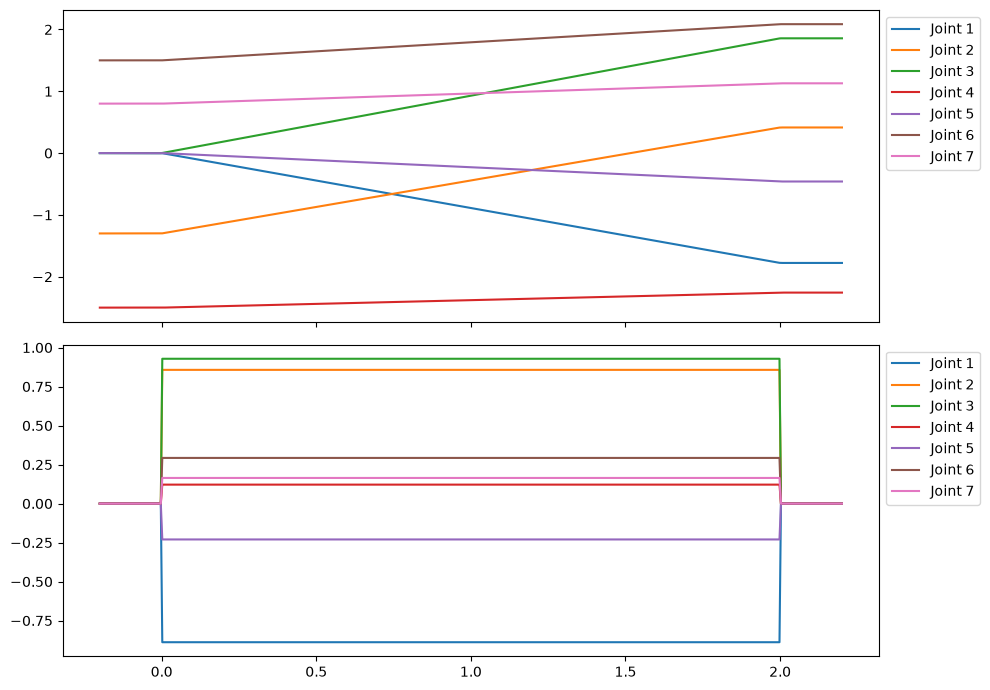

In [4]:
# Convert PyTorch tensors to NumPy
q_start = q0.detach().cpu().reshape(-1).numpy()
q_goal = q1.detach().cpu().reshape(-1).numpy()
T = 2.0
# Include a short stationary period before and after motion
time = np.linspace(-0.2, T + 0.2, 500)

# Linear interpolation
s = np.clip(time / T, 0.0, 1.0)
dq = q_goal - q_start


# franka is a robot that can be controlled in a deeper level so the profiles up to 2nd order need to be continuous not linear. jerk can be linear. anything below needs to be continuous


# Joint position
position = q_start[None, :] + s[:, None] * dq[None, :]

# Joint velocity: zero outside the motion interval
velocity = np.zeros_like(position)
moving = (time > 0) & (time < T)
velocity[moving] = dq / T

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for j in range(position.shape[1]):
    ax1.plot(time, position[:, j], label = f"Joint {j+1}")
    ax2.plot(time, velocity[:, j], label = f"Joint {j+1}")

ax1.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax2.legend(loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

##### Ruckig

In [5]:
from ruckig import Ruckig, InputParameter, Trajectory


q_start = q0.detach().cpu().reshape(-1).numpy()
q_goal = q1.detach().cpu().reshape(-1).numpy()

# Initialize Ruckig
dof = q_start.shape[0]
otg = Ruckig(dof)
inp = InputParameter(dof)
trajectory = Trajectory(dof)

# Start and target joint positions
inp.current_position = q_start.tolist()
inp.target_position = q_goal.tolist()

# Start and stop at rest
inp.current_velocity = [0.0] * dof
inp.current_acceleration = [0.0] * dof
inp.target_velocity = [0.0] * dof
inp.target_acceleration = [0.0] * dof

# EXAMPLE limits: replace with actual Franka joint limits
inp.max_velocity = [2.0] * dof       # rad/s
inp.max_acceleration = [10.0] * dof   # rad/s²
inp.max_jerk = [50.0] * dof           # rad/s³

# Calculate the entire trajectory
result = otg.calculate(inp, trajectory)

if int(result) < 0:
    raise RuntimeError(f"Ruckig failed: {result}")

print("Duration:", trajectory.duration)

Duration: 1.3282805323600768


##### Visualize Ruckig Trajectory

In [6]:
# plot the trajectory
t_slider = viz._server.gui.add_slider(
    "/t",
    min=0.0,
    max=1.0,
    step=0.01,
    initial_value=0.0,
)

t_slider = viz._server.gui.add_slider("/t", min=0, max=1, step=0.01, initial_value=0)
@t_slider.on_update
def on_slider_changed(event):
    t = t_slider.value * trajectory.duration
    qt = trajectory.at_time(t)[0]
    qt = torch.tensor(qt, dtype=viz._kinematics.device_cfg.dtype, device=viz._kinematics.device_cfg.device)
    jq = JointState.from_position(qt, joint_names=viz._kinematics.joint_names)
    viz.set_joint_state(jq)


##### Plot Ruckig Motion Profiles

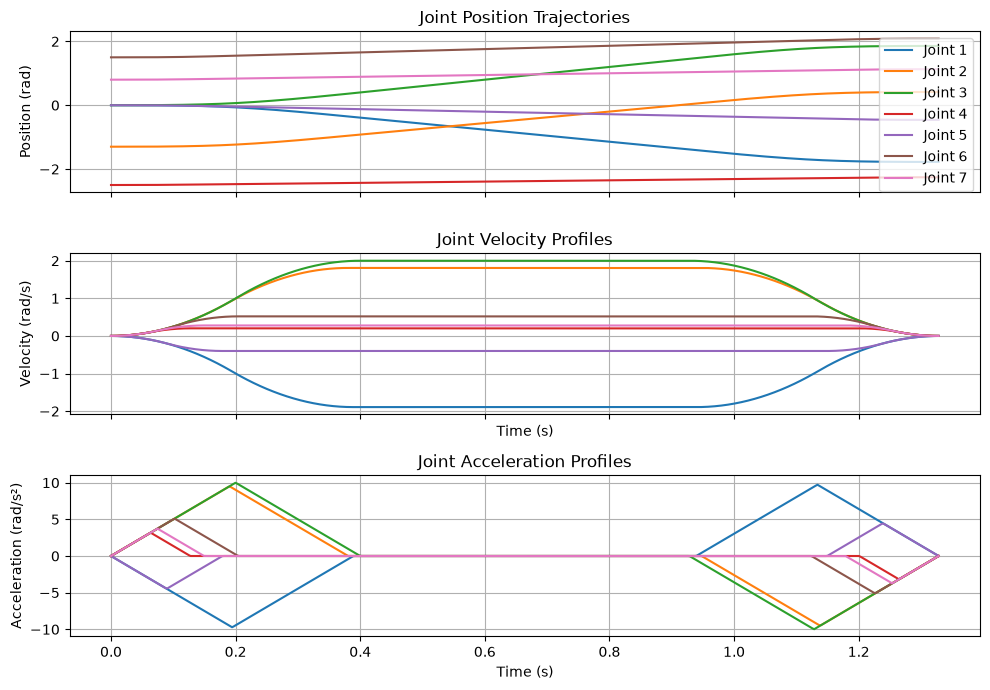

In [7]:
import matplotlib.pyplot as plt

times = np.linspace(0, trajectory.duration, 500)

positions = []
velocities = []
accelerations = []

for t in times:
    p, v, a = trajectory.at_time(float(t))
    positions.append(p)
    velocities.append(v)
    accelerations.append(a)

positions = np.asarray(positions)
velocities = np.asarray(velocities)
accelerations = np.asarray(accelerations)

fig, axes = plt.subplots(
    3, 1, figsize=(10, 7), sharex=True
)

for j in range(positions.shape[1]):
    axes[0].plot(times, positions[:, j], label = f"Joint {j+1}")
    axes[1].plot(times, velocities[:, j], label = f"Joint {j+1}")
    axes[2].plot(times, accelerations[:, j], label = f"Joint {j+1}")

axes[0].set_ylabel("Position (rad)")
axes[0].set_title("Joint Position Trajectories")
axes[0].legend()
axes[0].grid(True)

axes[1].set_ylabel("Velocity (rad/s)")
axes[1].set_xlabel("Time (s)")
axes[1].set_title("Joint Velocity Profiles")
axes[1].grid(True)

axes[2].set_ylabel("Acceleration (rad/s²)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Joint Acceleration Profiles")
axes[2].grid(True)

plt.tight_layout()
plt.show()

#### 2. Move Catersian (MoveL)

In [8]:
from scipy.spatial.transform import Rotation, Slerp
u = viz._kinematics.default_joint_state
F0 = viz._kinematics.compute_kinematics(u).tool_poses.get_link_pose("ee_link")

# time
t = np.linspace(0, 1, 500)

# interpolate frames between F0 and F1 using Ruckig
F0p = F0.position.cpu().numpy().squeeze()
F1p = F1.position.cpu().numpy().squeeze()
F0q = F0.quaternion.cpu().numpy().squeeze()
F1q = F1.quaternion.cpu().numpy().squeeze()

# interpolate position and orientation [uses slerp interpolation movin along a sphere surface]
positions = F0p[None, :] + t[:, None] * (F1p[None, :] - F0p[None, :])
rotations = Rotation.from_quat(np.stack([F0q, F1q]), scalar_first = True)
slerp = Slerp([0, 1], rotations)
quaternions = slerp(t).as_quat(scalar_first = True)
print("positions:", positions.shape)
print("quaternions:", quaternions.shape)
goal_pose = Pose.from_batch_list(np.concatenate([positions, quaternions], axis = 1))
t_slider = viz._server.gui.add_slider("/t", min=0, max=t.shape[0] - 1, step=1, initial_value=0)
@t_slider.on_update
def on_slider_changed(event):
    t = t_slider.value
    Ft = goal_pose[t]
    draw_frame(viz, Ft, "Ft")

positions: (500, 3)
quaternions: (500, 4)


##### Batch IK (discontinuity)

In [9]:
# compute IK
from curobo._src.state.state_joint_ops import repeat_joint_state
ik = InverseKinematics(InverseKinematicsCfg.create(robot=robot_config, num_seeds=1, max_batch_size = goal_pose.shape[0]))
goal = GoalToolPose.from_poses({"ee_link": goal_pose}, num_goalset=1)
joints = ik.solve_pose(goal).js_solution.position.squeeze(0)
print(joints.shape)
t_slider = viz._server.gui.add_slider("/t1", min=0, max=joints.shape[0] - 1, step=1, initial_value=0)
@t_slider.on_update
def on_slider_changed(event):
    t = t_slider.value
    qt = JointState.from_position(joints[t].squeeze(0), joint_names=viz._kinematics.joint_names)
    viz.set_joint_state(qt)

torch.Size([500, 1, 9])


##### IK with current state

In [10]:
# Initial robot configuration in the IK solver's joint order
# Use a fresh IK solver for the single-pose loop.
ik = InverseKinematics(
    InverseKinematicsCfg.create(
        robot=robot_config,
        num_seeds=1,
        max_batch_size=goal_pose.shape[0],
    )
)

u = viz._kinematics.default_joint_state.clone()
q0 = ik.get_active_js(u).position.reshape(1, -1)
current = JointState.from_position(q0.clone(),joint_names=ik.joint_names)
joints = []
for i in range(goal_pose.shape[0]):
    goal = GoalToolPose.from_poses({"ee_link": goal_pose[i]},num_goalset=1)
    result = ik.solve_pose(goal_tool_poses=goal, current_state=current,return_seeds=1)
    q_next = result.solution[0, 0].detach().clone()
    current = JointState(position=q_next.unsqueeze(0),joint_names=ik.joint_names)
    joints.append(result.js_solution.position[0, 0].detach().clone())

joints = torch.stack(joints, dim=0)

## Curobo Motion Planning

#### 1. Create Motion Planner

In [11]:
from pathlib import Path
from curobo.motion_planner import MotionPlanner, MotionPlannerCfg
viz = ViserVisualizer(content_path=copy.deepcopy(robot_config), add_control_frames = False)
scene_file_path = str(Path.cwd() / "table.yml")
mp_config = MotionPlannerCfg.create(
        robot=robot_config,
        scene_model=scene_file_path,
)
planner = MotionPlanner(mp_config)
planner.warmup(enable_graph=True, num_warmup_iterations=5)
scene = mp_config.scene_collision_cfg.scene_model
viz.add_scene(scene)
viz._server.scene.show()

#### 2. Joint -> frame (plan pose)

In [12]:
from scipy.spatial.transform import Rotation as R

rot_matrix = np.array([[1, 0, 0],
                       [0, -1, 0],
                       [0, 0, -1]])
quat = R.from_matrix(rot_matrix).as_quat(scalar_first = True)
F0 = Pose.from_list([.5, 0, .025, quat[0], quat[1], quat[2], quat[3]])

goal = GoalToolPose.from_poses({"ee_link": F0}, num_goalset=1)
q_start = JointState.from_position(planner.default_joint_state.position.unsqueeze(0), joint_names=planner.joint_names)
mp_result = planner.plan_pose(goal, q_start)
joints = mp_result.js_solution.position.squeeze(0).squeeze(0)
t_slider = viz._server.gui.add_slider("/t", min=0, max=joints.shape[0] - 1, step=1, initial_value=0)
@t_slider.on_update
def on_slider_changed(event):
    t = int(t_slider.value)
    qt = JointState.from_position(joints[t, :], joint_names=viz._kinematics.joint_names)
    viz.set_joint_state(qt)

#### 3. Joint -> Joint (plan_cspace)

In [13]:
ik_cfg = InverseKinematicsCfg.create(robot=robot_config,
                                     scene_model=scene_file_path)
ik = InverseKinematics(ik_cfg)
ik_result =ik.solve_pose(goal)
q_target = ik.get_active_js(ik_result.js_solution.squeeze(0)).position
q_target = JointState.from_position(q_target, joint_names=ik.joint_names)
mp_result = planner.plan_cspace(goal_state = q_target, current_state = q_start)
joints = mp_result.js_solution.position.squeeze(0).squeeze(0)

#### 4. Plan Grasp

##### Vertical Z

In [14]:
rot_matrix = np.array([[1, 0, 0],
                       [0, -1, 0],
                       [0, 0, -1]])
quat = R.from_matrix(rot_matrix).as_quat(scalar_first = True)
F0 = Pose.from_list([.5, 0, .025, quat[0], quat[1], quat[2], quat[3]])
goal = GoalToolPose.from_poses({"ee_link": F0}, num_goalset=1)
grasp_plan_result = planner.plan_grasp(grasp_poses = goal, 
                                       current_state = q_start, 
                                       plan_grasp_to_lift = False,
                                       grasp_approach_axis = 'z',
                                       grasp_approach_offset = -0.15,
                                       grasp_approach_in_tool_frame = True)
approach_joints = grasp_plan_result.approach_trajectory.position.squeeze(0).squeeze(0)
grasp_joints = grasp_plan_result.grasp_trajectory.position.squeeze(0).squeeze(0)
joints = torch.cat([approach_joints, grasp_joints], dim=0)

t_slider = viz._server.gui.add_slider("/t", min=0, max=joints.shape[0] - 1, step=1, initial_value=0)
@t_slider.on_update
def on_slider_changed(event):
    t = int(t_slider.value)
    qt = JointState.from_position(joints[t, :], joint_names=viz._kinematics.joint_names)
    viz.set_joint_state(qt)

##### Tilt Grasp

In [15]:
# new goal
rot_matrix = np.array([[1, 0, 0],
                       [0, -1, 0],
                       [0, 0, -1]])
R0 = R.from_euler('xyz', [0, 45, 0], degrees=True).as_matrix()
rot_matrix = R0 @ rot_matrix
quat = R.from_matrix(rot_matrix).as_quat(scalar_first = True)
F0 = Pose.from_list([.5, 0, .025, quat[0], quat[1], quat[2], quat[3]])
goal = GoalToolPose.from_poses({"ee_link": F0}, num_goalset=1)

grasp_plan_result = planner.plan_grasp(grasp_poses = goal, 
                                       current_state = q_start, 
                                       plan_grasp_to_lift = False, 
                                       grasp_approach_axis = 'z',
                                       grasp_approach_offset = -0.15,
                                       grasp_approach_in_tool_frame = True) # False will grasp from top
approach_joints = grasp_plan_result.approach_trajectory.position.squeeze(0).squeeze(0)
grasp_joints = grasp_plan_result.grasp_trajectory.position.squeeze(0).squeeze(0)
joints = torch.cat([approach_joints, grasp_joints], dim=0)

t_slider = viz._server.gui.add_slider("/t", min=0, max=joints.shape[0] - 1, step=1, initial_value=0)
@t_slider.on_update
def on_slider_changed(event):
    t = int(t_slider.value)
    qt = JointState.from_position(joints[t, :], joint_names=viz._kinematics.joint_names)
    viz.set_joint_state(qt)

#### 5. Pick and Place

##### Load Shelf Scene

In [ ]:
from pathlib import Path
from curobo.motion_planner import MotionPlanner, MotionPlannerCfg
viz = ViserVisualizer(content_path=copy.deepcopy(robot_config), add_control_frames = False, visualize_robot_spheres = True)
scene_file_path = str(Path.cwd() / "shelf.yml")
mp_config = MotionPlannerCfg.create(
        robot=robot_config,
        scene_model=scene_file_path,
)
planner = MotionPlanner(mp_config)
planner.warmup(enable_graph=True, num_warmup_iterations=5)#need to use warmup to initialize the algo so that it isnt laggy
scene = mp_config.scene_collision_cfg.scene_model
viz.add_scene(scene)
viz._server.scene.show()

#### Set Pick frame and Place frame

In [17]:
from scipy.spatial.transform import Rotation as R
rot_matrix = np.array([[0, 1, 0],
                       [1, 0, 0],
                       [0, 0, -1]])
quat = R.from_matrix(rot_matrix).as_quat(scalar_first = True)
F_pick = Pose.from_list([-0.6, 0.0, 0.03, quat[0], quat[1], quat[2], quat[3]])
F_place = Pose.from_list([0.46, 0.25, 0.45, quat[0], quat[1], quat[2], quat[3]])
draw_frame(viz, F_pick, "pick")
draw_frame(viz, F_place, "place")

##### Plan Pick

In [24]:
q_pick_start = JointState.from_position(planner.default_joint_state.position.unsqueeze(0), joint_names=planner.joint_names)
pick_goal = GoalToolPose.from_poses({"ee_link": F_pick}, num_goalset=1)
pick_result = planner.plan_grasp(grasp_poses = pick_goal, current_state = q_pick_start)
pick_approach_joints = pick_result.approach_trajectory.position.squeeze(0).squeeze(0)
pick_grasp_joints = pick_result.grasp_trajectory.position.squeeze(0).squeeze(0)
pick_lift_joints = pick_result.lift_trajectory.position.squeeze(0).squeeze(0)
joints = torch.cat([pick_approach_joints, pick_grasp_joints, pick_lift_joints], dim=0)
t_slider = viz._server.gui.add_slider("/t", min=0, max=joints.shape[0] - 1, step=1, initial_value=0)
@t_slider.on_update
def on_slider_changed(event):
    t = int(t_slider.value)
    qt = JointState.from_position(joints[t, :], joint_names=viz._kinematics.joint_names)
    viz.set_joint_state(qt)

#### Plan Place

In [25]:
q_place_start = JointState.from_position(pick_lift_joints[-1, :7].unsqueeze(0), joint_names=planner.joint_names)
place_goal = GoalToolPose.from_poses({"ee_link": F_place}, num_goalset=1)
place_result = planner.plan_grasp(grasp_poses = place_goal, 
                                  current_state = q_place_start,
                                  plan_grasp_to_lift = False,
                                  grasp_approach_in_tool_frame = False,
                                  grasp_approach_axis = 'x',
                                  grasp_approach_offset = -0.15)
place_approach_joints = place_result.approach_trajectory.position.squeeze(0).squeeze(0)
place_grasp_joints = place_result.grasp_trajectory.position.squeeze(0).squeeze(0)
joints = torch.cat([place_approach_joints, place_grasp_joints], dim=0)

viz._server.gui.reset()
new_cube = viz._server.scene.add_box("grasp_cube", dimensions=[0.25, 0.06, 0.06])
t_slider = viz._server.gui.add_slider("/t", min=0, max=joints.shape[0] - 1, step=1, initial_value=0)
@t_slider.on_update
def on_slider_changed(event):
    t = int(t_slider.value)
    qt = JointState.from_position(joints[t, :7], joint_names=viz._kinematics.joint_names)
    viz.set_joint_state(qt)

    # draw cube
    ee = viz._kinematics.compute_kinematics(qt).tool_poses.get_link_pose("ee_link")
    new_cube.wxyz = ee.quaternion.cpu().numpy().squeeze()
    new_cube.position = ee.position.cpu().numpy().squeeze()

(viser) Connection closed (1, 0 total)

##### Attach Spheres

In [20]:
from curobo.scene import Cuboid

robot_config["robot_cfg"]["kinematics"]["extra_collision_spheres"]["attached_object"] = 8
robot_config["robot_cfg"]["kinematics"]["extra_links"]["attached_object"]['parent_link_name'] = "ee_link"
mp_config = MotionPlannerCfg.create(
        robot=robot_config,
        scene_model=scene_file_path,
)
planner = MotionPlanner(mp_config)
q_attach = JointState.from_position(pick_lift_joints[0, :7].unsqueeze(0), joint_names=planner.joint_names)

pickup_cube_local = Cuboid(
    name="pickup_cube_attached",
    dims=[0.25, 0.06, 0.06],
    pose=[0, 0, 0, 1, 0, 0, 0],
)
planner.attachment_manager.attach(q_attach, [pickup_cube_local])
viz._kinematics = planner.kinematics
viz.update_robot_spheres(q_attach)
viz.set_joint_state(q_attach)

##### Plan Place with Attachement

In [21]:
place_result = planner.plan_grasp(grasp_poses = place_goal, 
                                  current_state = q_place_start,
                                  plan_grasp_to_lift = False,
                                  grasp_approach_in_tool_frame = False,
                                  grasp_approach_axis = 'x',
                                  grasp_approach_offset = -0.15)
place_approach_joints = place_result.approach_trajectory.position.squeeze(0).squeeze(0)
place_grasp_joints = place_result.grasp_trajectory.position.squeeze(0).squeeze(0)
joints = torch.cat([place_approach_joints, place_grasp_joints], dim=0)

viz._server.gui.reset()
t_slider = viz._server.gui.add_slider("/t", min=0, max=joints.shape[0] - 1, step=1, initial_value=0)
@t_slider.on_update
def on_slider_changed(event):
    t = int(t_slider.value)
    qt = JointState.from_position(joints[t, :7], joint_names=viz._kinematics.joint_names)
    viz.set_joint_state(qt)

    # draw cube
    ee = viz._kinematics.compute_kinematics(qt).tool_poses.get_link_pose("ee_link")
    new_cube.wxyz = ee.quaternion.cpu().numpy().squeeze()
    new_cube.position = ee.position.cpu().numpy().squeeze()


##### Sphere Fit Type

In [22]:
from curobo.sphere_fit import SphereFitType
robot_config["robot_cfg"]["kinematics"]["extra_collision_spheres"]["attached_object"] = 60
robot_config["robot_cfg"]["kinematics"]["extra_links"]["attached_object"]['parent_link_name'] = "ee_link"
mp_config = MotionPlannerCfg.create(
        robot=robot_config,
        scene_model=scene_file_path,
)
planner = MotionPlanner(mp_config)
q_attach = JointState.from_position(pick_lift_joints[0, :7].unsqueeze(0), joint_names=planner.joint_names)

pickup_cube_local = Cuboid(
    name="pickup_cube_attached",
    dims=[0.25, 0.06, 0.06],
    pose=[0, 0, 0, 1, 0, 0, 0],
)
planner.attachment_manager.attach(q_attach, [pickup_cube_local], sphere_fit_type=SphereFitType.SURFACE)
viz._kinematics = planner.kinematics
viz.update_robot_spheres(q_attach)
viz.set_joint_state(q_attach)